## Gráficos TP Big Data 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('data/estadistica_fin_de_cursado.xlsx')
info_materias = pd.read_excel('data/cod_materias.xlsx')

In [2]:
# Para que no acorte los str al imprimir los dataframes
pd.set_option('display.max_colwidth', None)

In [3]:
# Visualizamos las primeras filas del dataset 
info_materias.head()

,Código,Materia,Carrera
0,1,"Taller de Ciencia, Tecnología y Sociedad",(T-001) - Tecnicatura Universitaria en Automatización y Control
1,2,Matemática general,(T-001) - Tecnicatura Universitaria en Automatización y Control
2,3,Medios de representación y dibujo mecánico,(T-001) - Tecnicatura Universitaria en Automatización y Control
3,4,Herramientas computacionales y programación para la ingeniería y la ciencia,(T-001) - Tecnicatura Universitaria en Automatización y Control
4,5,Inglés,(T-001) - Tecnicatura Universitaria en Automatización y Control


In [4]:
# Apariciones únicas de cada carrera
print(info_materias['Carrera'].unique())

['(T-001) - Tecnicatura Universitaria en Automatización y Control'
 '(T-002) - Tecnicatura Universitaria en Gestión de las Organizaciones'
 '(T-003) - Tecnicatura Universitaria en Logística y Transporte'
 '(L-002) - Licenciatura en Logística y Transporte'
 '(T-004) - Tecnicatura Universitaria en Acompañamiento Terapéutico'
 '(T-005) - Tecnicatura Universitaria en Comunicación Digital'
 '(T-006) - Tecnicatura Universitaria en Diseño y Desarrollo de Producto'
 '(L-003) - Licenciatura en Administración'
 '(L-001) - Licenciatura en Ciencias de Datos'
 '(CCC-001) - Licenciatura en  Enseñanza de la Matemática - CCC'
 '(L-004) - Licenciatura en Ciencia Política'
 '(T-007) - Tecnicatura Universitaria en Prótesis Dental'
 '(T-008) - Tecnicatura Universitaria en Programación']


In [5]:
# Separamos en dos partes el str de Carrera, en: código y nombre
info_materias['cod_carrera'] = info_materias['Carrera'].str.split(' - ', n=1).str[0]
info_materias['cod_carrera'] = info_materias['cod_carrera'].str.strip('()')
info_materias['Carrera'] = info_materias['Carrera'].str.split(' - ', n=1).str[1]

# Nos quedamos sólo con las apariciones únicas de cada carrera
info_carreras = info_materias.drop_duplicates(subset=['cod_carrera', 'Carrera'])
info_carreras = info_carreras[['cod_carrera', 'Carrera']]
info_carreras = info_carreras.set_index('cod_carrera')

In [6]:
# Abreviación de los nombres de las carreras
info_carreras['Carrera_abv'] = (
    info_carreras['Carrera']
    .str.replace('Licenciatura en', 'Lic.', regex=False)
    .str.replace('Tecnicatura Universitaria en', 'Tec.', regex=False)
    .str.replace('Organizaciones', 'Orgs.', regex=False)
    .str.replace('de la Matemática', 'de Matemática', regex=False)
    .str.replace('Acompañamiento', 'Acom.', regex=False)
    .str.replace('Diseño y Desarrollo', 'Dis. y Des.', regex=False)
    .str.replace(' - CCC', '', regex=False)
)


In [7]:
info_carreras

,Carrera,Carrera_abv
cod_carrera,,
T-001,Tecnicatura Universitaria en Automatización y Control,Tec. Automatización y Control
T-002,Tecnicatura Universitaria en Gestión de las Organizaciones,Tec. Gestión de las Orgs.
T-003,Tecnicatura Universitaria en Logística y Transporte,Tec. Logística y Transporte
L-002,Licenciatura en Logística y Transporte,Lic. Logística y Transporte
T-004,Tecnicatura Universitaria en Acompañamiento Terapéutico,Tec. Acom. Terapéutico
T-005,Tecnicatura Universitaria en Comunicación Digital,Tec. Comunicación Digital
T-006,Tecnicatura Universitaria en Diseño y Desarrollo de Producto,Tec. Dis. y Des. de Producto
L-003,Licenciatura en Administración,Lic. Administración
L-001,Licenciatura en Ciencias de Datos,Lic. Ciencias de Datos


In [8]:
# Echamos un vistazo al dataset de estadísticas de fin de curso
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MATERIA        303 non-null    object
 1   COMISION       303 non-null    int64 
 2   TOTAL_ALUMNOS  303 non-null    int64 
 3   ABANDONO       303 non-null    int64 
 4   INSUFICIENTE   303 non-null    int64 
 5   LIBRE          303 non-null    int64 
 6   PROMOCIONO     303 non-null    int64 
 7   REGULAR        303 non-null    int64 
 8   CODIGO         303 non-null    int64 
 9   CARRERA        303 non-null    object
 10  TURNO          122 non-null    object
 11  DIA            122 non-null    object
 12  HORA           122 non-null    object
 13  MODALIDAD      122 non-null    object
 14  SEDE           117 non-null    object
dtypes: int64(8), object(7)
memory usage: 35.6+ KB


In [9]:
# Hacemos un subset con las columnas de interés
data = data.drop(columns=['MATERIA', 'TURNO', 'DIA', 'HORA', 'MODALIDAD', 'SEDE'])

In [10]:
# Creamos la columna finalizacion como regulares + promocionados para cada registro
data['FINALIZACION'] = data['PROMOCIONO'] + data['REGULAR']

# Agrupamos por carrera y sumamos el total de las cantidades de alumnos
data_agg = data.drop(columns=['CODIGO', 'COMISION']).groupby(['CARRERA']).sum()

# Normalizamos (convertimos a proporción sobre el total de alumnos)
for col in data_agg.iloc[:, 1:].columns:
    data_agg[col] = data_agg[col]/data_agg['TOTAL_ALUMNOS']

# Ordenamos de forma ascendente según la proporción de finalización
data_agg.sort_values('FINALIZACION', inplace=True)

In [11]:
# Imprimimos para ver el resultado
data_agg

,TOTAL_ALUMNOS,ABANDONO,INSUFICIENTE,LIBRE,PROMOCIONO,REGULAR,FINALIZACION
CARRERA,,,,,,,
T-003,866,0.094688,0.072748,0.407621,0.185912,0.236721,0.422633
L-002,1104,0.070652,0.057065,0.408514,0.202899,0.259964,0.462862
T-001,1500,0.040000,0.039333,0.431333,0.132667,0.356667,0.489333
L-003,1287,0.108003,0.097125,0.284382,0.152292,0.357420,0.509713
T-006,723,0.091286,0.096819,0.297372,0.109267,0.405256,0.514523
T-008,2336,0.083904,0.065925,0.321490,0.145120,0.383562,0.528682
L-004,1206,0.088723,0.057214,0.325041,0.174129,0.354892,0.529022
T-007,402,0.243781,0.007463,0.218905,0.338308,0.191542,0.529851
L-001,1288,0.096273,0.194876,0.173137,0.166149,0.369565,0.535714


In [12]:
# Join entre lo calculado y los nombres abreviados de las carreras
data_full = data_agg.join(info_carreras['Carrera_abv'], how='left')

# Seteamos como índice el nombre abreviado de las carreras para que aparezcan en el gráfico
data_full.set_index('Carrera_abv', drop=True, inplace=True)

In [13]:
# Imprimimos el resultado
data_full

,TOTAL_ALUMNOS,ABANDONO,INSUFICIENTE,LIBRE,PROMOCIONO,REGULAR,FINALIZACION
Carrera_abv,,,,,,,
Tec. Logística y Transporte,866,0.094688,0.072748,0.407621,0.185912,0.236721,0.422633
Lic. Logística y Transporte,1104,0.070652,0.057065,0.408514,0.202899,0.259964,0.462862
Tec. Automatización y Control,1500,0.040000,0.039333,0.431333,0.132667,0.356667,0.489333
Lic. Administración,1287,0.108003,0.097125,0.284382,0.152292,0.357420,0.509713
Tec. Dis. y Des. de Producto,723,0.091286,0.096819,0.297372,0.109267,0.405256,0.514523
Tec. Programación,2336,0.083904,0.065925,0.321490,0.145120,0.383562,0.528682
Lic. Ciencia Política,1206,0.088723,0.057214,0.325041,0.174129,0.354892,0.529022
Tec. Prótesis Dental,402,0.243781,0.007463,0.218905,0.338308,0.191542,0.529851
Lic. Ciencias de Datos,1288,0.096273,0.194876,0.173137,0.166149,0.369565,0.535714


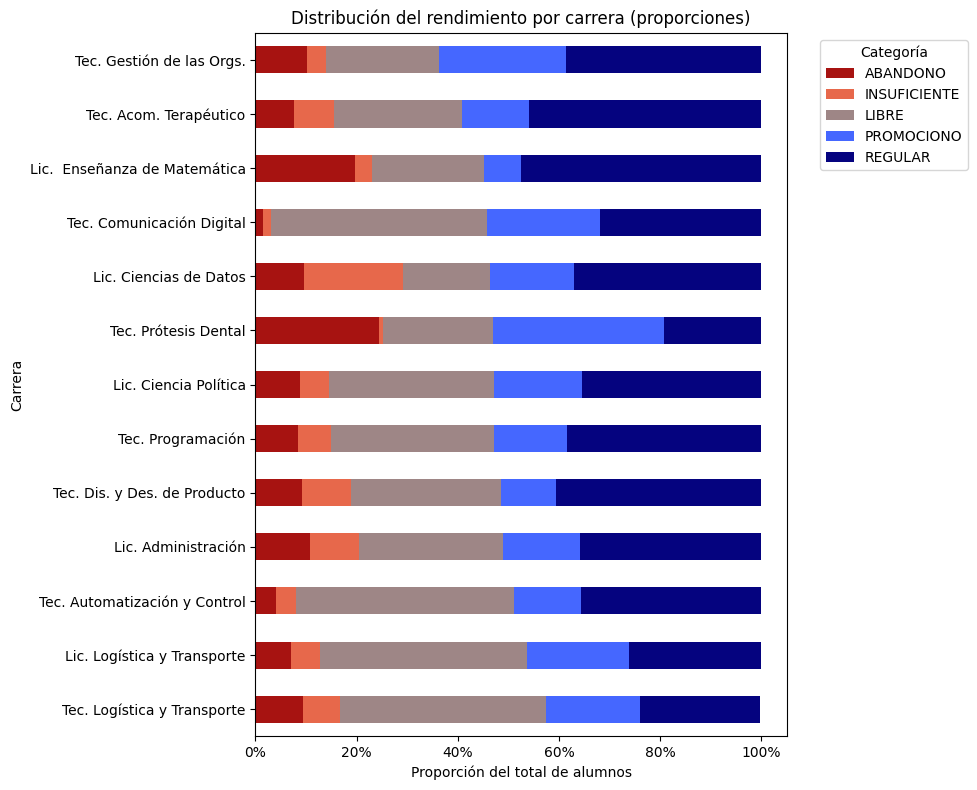

In [14]:
# Definimos la paleta de colores personalizada
colors = ["#A71311", "#E7684B", "#9E8686", "#4567FF", "#05037F"]

# Tomamos todas las columnas (proporciones por categoría) excepto total_alumnos y finalizacion
data_full.iloc[:, 1:6].plot(
    kind='barh',
    stacked=True,
    color=colors,
    figsize=(10,8)
    
)

plt.title('Distribución del rendimiento por carrera (proporciones)')
plt.xlabel('Proporción del total de alumnos')
plt.ylabel('Carrera')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x:.0%}') # convierte la escala a porcentajes de 0 al 100
plt.tight_layout()
plt.show()

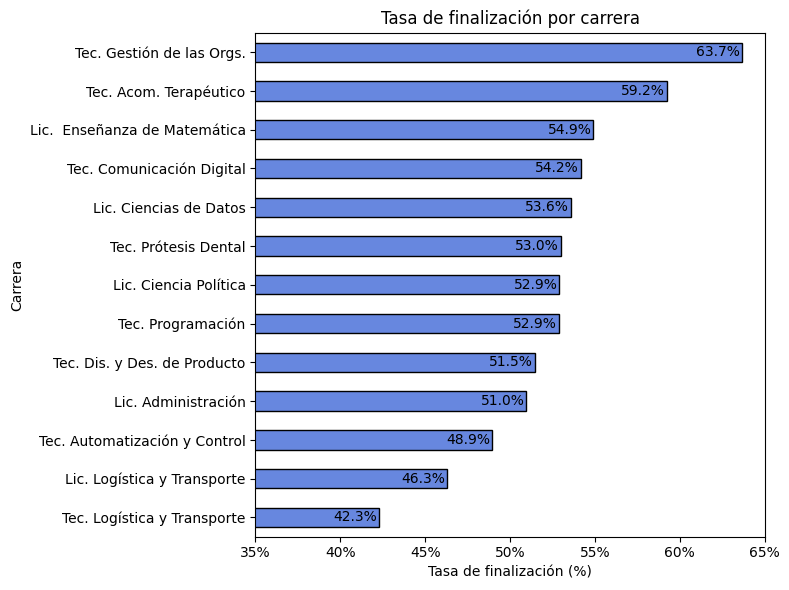

In [15]:
ax = data_full['FINALIZACION'].plot(
    kind='barh',
    figsize=(8, 6),
    color="#6787DF",
    edgecolor='black'
)

ax.set_xlim(0.35, 0.65)
plt.xlabel('Tasa de finalización (%)')
plt.ylabel('Carrera')
plt.title('Tasa de finalización por carrera')

# Agregamos los valores al final de cada barra
for i, v in enumerate(data_full['FINALIZACION']):
    plt.text(v-0.027, i, f'{v*100:.1f}%', va='center')
plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x:.0%}') # convierte la escala a porcentajes de 0 al 100
plt.tight_layout()
plt.show()


In [16]:
# Importamos información sobre la oferta académica
oferta_materias = pd.read_excel('data/oferta_2024_limpia.xlsx')

# Echamos un vistazo
oferta_materias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   COD. ASIG      305 non-null    int64  
 1   COMISIÓN       305 non-null    int64  
 2   CARGA HORARIA  304 non-null    float64
 3   TURNO          305 non-null    object 
 4   DIA            305 non-null    object 
 5   HORA           305 non-null    object 
 6   MODALIDAD      305 non-null    object 
 7   SEDE           305 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 19.2+ KB


In [17]:
# Imprimimos la cantidad de apariciones de cada valor en la columna MODALIDAD
oferta_materias['MODALIDAD'].value_counts()

MODALIDAD
presencial                                105
presencial                                 69
virtual                                    29
4 hs presencial y 2 virtual                22
Presencial                                 18
virtual                                    15
peesencial                                 10
virtual (con encuentros presenciales)       5
4 hs presencial y 2 virtual                 4
presencial y 2 hs virtual                   4
4 hs presenciales y 2 virtuales             4
4 presencial y 2 virtual                    3
4 Presencial, 2 virtual                     3
4 hs presencial 2 virtual                   2
3 hs presencial 3 virtual                   1
 4 hs presencial 2 virtual                  1
 presencial                                 1
2 presencial y 4  virtual                   1
2 presencial y 4 virtual                    1
2 hs presencial y 2 virtual                 1
´presencial                                 1
4 presenciales y 2 virtu

In [18]:
# Limpieza de columna MODALIDAD
def limpiar_modalidad(valor):
    # Tomamos el input, convertimos a string en minúsculas y eliminamos posibles espacios al inicio o final
    valor = str(valor).lower().strip()

    # Casos claramente presenciales
    if valor in ['presencial', 'peesencial', '´presencial']:
        return 'presencial'

    # Casos claramente virtuales
    elif valor == 'virtual':
        return 'virtual'

    # Casos mixtos o combinados
    elif 'y' in valor or 'virtual' in valor and 'presencial' in valor:
        return 'bimodal'
    elif any(palabra in valor for palabra in [
        'hs presencial', 'presencial y', 'virtual (con encuentros presenciales)',
        'presenciales y', 'presencial,', 'presencial y', 'presenciales,', 'hs prácticas,'
    ]):
        return 'bimodal'

    # Fallback por si algo no entra en los casos anteriores
    else:
        return 'null'

# Aplicar la función
oferta_materias['MODALIDAD_LIMPIA'] = oferta_materias['MODALIDAD'].apply(limpiar_modalidad)

# Verificar resultados
print(oferta_materias['MODALIDAD_LIMPIA'].value_counts())


MODALIDAD_LIMPIA
presencial    204
bimodal        57
virtual        44
Name: count, dtype: int64


In [19]:
# Imprimimos la cantidad de apariciones de cada valor en la columna TURNO
oferta_materias['TURNO'].value_counts()

TURNO
noche      181
mañana      68
tarde       50
mañana       4
mañama       1
Noche        1
Name: count, dtype: int64

In [20]:
# Limpieza de columna TURNO
def limpiar_turno(valor):
    # Tomamos el input, convertimos a string en minúsculas y eliminamos posibles espacios al inicio o final
    valor = str(valor).lower().strip()

    # Casos de turno mañana
    if valor in ['mañana', 'manana', 'mañama']:
        return 'mañana'
    
    # Casos de turno tarde
    elif valor == 'tarde':
        return 'tarde'
    
    # Casos de turno noche
    elif valor == 'noche':
        return 'noche'
    
    # Fallback
    else:
        return 'null' 

# Aplicar la función
oferta_materias['TURNO_LIMPIO'] = oferta_materias['TURNO'].apply(limpiar_turno)

# Verificar resultados
print(oferta_materias['TURNO_LIMPIO'].value_counts())


TURNO_LIMPIO
noche     182
mañana     73
tarde      50
Name: count, dtype: int64


In [21]:
# Hacemos un subset con las columnas de interés
oferta_limpia = oferta_materias.loc[:, ['COD. ASIG', 'COMISIÓN', 'MODALIDAD_LIMPIA', 'TURNO_LIMPIO']].copy()
oferta_limpia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   COD. ASIG         305 non-null    int64 
 1   COMISIÓN          305 non-null    int64 
 2   MODALIDAD_LIMPIA  305 non-null    object
 3   TURNO_LIMPIO      305 non-null    object
dtypes: int64(2), object(2)
memory usage: 9.7+ KB


In [22]:
# Recordamos el dataset de estadísticas de fin de curso
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   COMISION       303 non-null    int64 
 1   TOTAL_ALUMNOS  303 non-null    int64 
 2   ABANDONO       303 non-null    int64 
 3   INSUFICIENTE   303 non-null    int64 
 4   LIBRE          303 non-null    int64 
 5   PROMOCIONO     303 non-null    int64 
 6   REGULAR        303 non-null    int64 
 7   CODIGO         303 non-null    int64 
 8   CARRERA        303 non-null    object
 9   FINALIZACION   303 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 23.8+ KB


In [23]:
# Realizamos un left join entre data y oferta_limpia
data_merged = data.merge(oferta_limpia, left_on=['CODIGO', 'COMISION'], right_on=['COD. ASIG', 'COMISIÓN'], how='left')

In [24]:
# Echamos un vistazo al resultado
data_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   COMISION          303 non-null    int64  
 1   TOTAL_ALUMNOS     303 non-null    int64  
 2   ABANDONO          303 non-null    int64  
 3   INSUFICIENTE      303 non-null    int64  
 4   LIBRE             303 non-null    int64  
 5   PROMOCIONO        303 non-null    int64  
 6   REGULAR           303 non-null    int64  
 7   CODIGO            303 non-null    int64  
 8   CARRERA           303 non-null    object 
 9   FINALIZACION      303 non-null    int64  
 10  COD. ASIG         297 non-null    float64
 11  COMISIÓN          297 non-null    float64
 12  MODALIDAD_LIMPIA  297 non-null    object 
 13  TURNO_LIMPIO      297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 33.3+ KB


In [25]:
# Imprimimos la cantidad exacta de valores nulos
data_merged.isnull().sum().sum()

24

In [26]:
# Borramos los null
data_merged.dropna(inplace=True)

# Normalizamos la columna finalización para obtener la proporción sobre el total de alumnos
data_merged['FINALIZACION'] = data_merged['FINALIZACION']/data_merged['TOTAL_ALUMNOS']

In [27]:
# Creamos una tabla con el promedio de la tasa de finalización para 
# cada combinación de las categorías de modalidad y turno
table = data_merged.pivot_table(['FINALIZACION'], ['MODALIDAD_LIMPIA'], ['TURNO_LIMPIO'], margins=True)
table

FINALIZACION                              
TURNO_LIMPIO           mañana     noche     tarde       All
MODALIDAD_LIMPIA                                           
bimodal              0.384695  0.574846  0.399496  0.492600
presencial           0.575987  0.606500  0.538661  0.588460
virtual              0.469834  0.636037  0.527006  0.589893
All                  0.528763  0.605619  0.508264  0.570597

In [28]:
# Renombramos y reordenamos los índices y las columnas para obtener una tabla visualmente más limpia
table.columns = ["Mañana", "Noche", "Tarde", "Promedio Total"]
table.index = ["Bimodal", "Presencial", "Virtual", "Promedio Total"]
table = table.reindex(index=["Presencial", "Bimodal", "Virtual", "Promedio Total"], columns=["Mañana", "Tarde", "Noche", "Promedio Total"])
table

,Mañana,Tarde,Noche,Promedio Total
Presencial,0.575987,0.538661,0.606500,0.588460
Bimodal,0.384695,0.399496,0.574846,0.492600
Virtual,0.469834,0.527006,0.636037,0.589893
Promedio Total,0.528763,0.508264,0.605619,0.570597


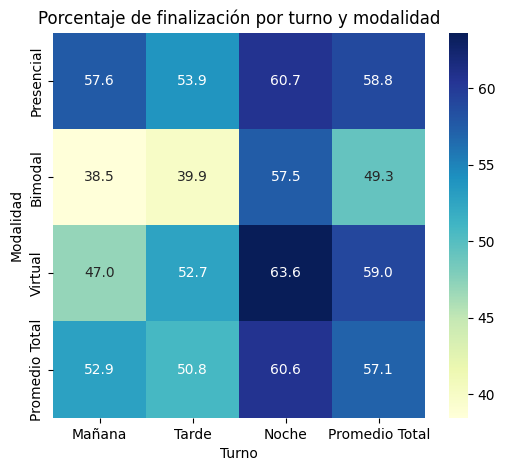

In [29]:
# Graficamos un heatmap para la tabla resultante
plt.figure(figsize=(6,5))
sns.heatmap(table*100, annot=True, cmap="YlGnBu", fmt=".1f")

plt.title("Porcentaje de finalización por turno y modalidad")
plt.ylabel("Modalidad")
plt.xlabel("Turno")
plt.show()